<a href="https://colab.research.google.com/github/aswinss949/DSC-DEMO-PROJECT/blob/main/unsupervised_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#OBJECTIVE
The objective of this project is to use unsupervised learning techniques to identify hidden socioeconomic groups within the adult population dataset instead of predicting predefined income labels.
The preprocessing phase is performed to prepare the dataset for clustering algorithms such as KMeans and Agglomerative Clustering.




# Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder  #for scaling
import matplotlib.pyplot as plt  #ml models
from sklearn.cluster import KMeans #clustering

# Data Analysis

In [ ]:
df_adult= pd.read_csv("/content/adult_dataset.csv")

In [ ]:
df_adult.head(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K


In [ ]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [ ]:
df_adult.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


# Task 1 : Data Pre Processing

## Duplicate Removal

In [ ]:
duplicate_rows = df_adult.duplicated().sum()  # Check duplicate rows

In [ ]:
print(duplicate_rows)

16


In [ ]:
duplicate_cols = df_adult.T.duplicated().sum()  # Check duplicate columns

In [ ]:
print(duplicate_cols)

0


## Missing Values Analysis and Handling

In [ ]:
num_cols =  df_adult.select_dtypes(include=['int64', 'float64']).columns
cat_cols =  df_adult.select_dtypes(include=['object']).columns

In [ ]:
num_cols

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [ ]:
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

In [ ]:
missing_percent = df_adult.isna().sum() / len(df_adult) * 100
missing_percent = missing_percent[missing_percent > 0]
missing_percent.sort_values(ascending=False)

,0
workclass,6.883420
occupation,6.873183
native-country,5.538266
age,4.999795
hours-per-week,4.999795


## Replace ? with NaN

In [ ]:
print((df_adult== '?').sum())

age                  0
workclass         1763
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1758
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     555
income               0
dtype: int64


In [ ]:
df_adult.isna().sum()   #Before

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [ ]:
df_adult.replace('?', np.nan, inplace=True)

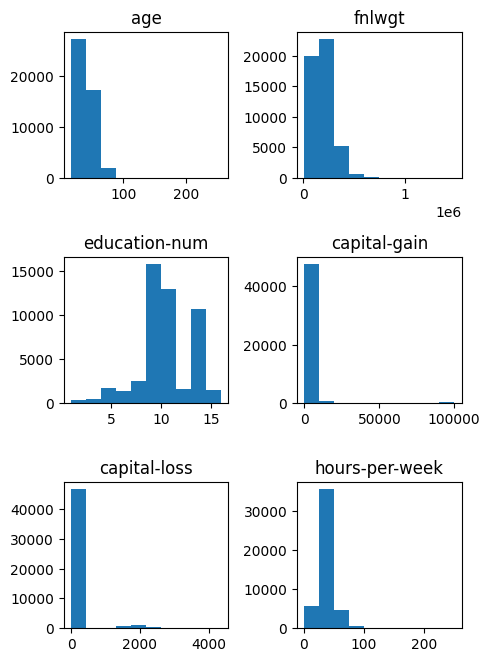

In [ ]:
plt.figure(figsize=(5,20))
for i, col in enumerate(num_cols, 1):
    plt.subplot(9,2, i)
    plt.hist(df_adult[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
#from the chart,we saw that al,colums are skewed in nature.
#we can use median to replace every column

df_adult['age'].fillna(df_adult['age'].median(), inplace=True)
df_adult['fnlwgt'].fillna(df_adult['fnlwgt'].median(), inplace=True)
df_adult['education-num'].fillna(df_adult['education-num'].median(), inplace=True)
df_adult['capital-gain'].fillna(df_adult['capital-gain'].median(), inplace=True)
df_adult['capital-loss'].fillna(df_adult['capital-loss'].median(), inplace=True)
df_adult['hours-per-week'].fillna(df_adult['hours-per-week'].median(), inplace=True)

df_adult.isna().sum()

/tmp/ipykernel_12906/1948884541.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adult['age'].fillna(df_adult['age'].median(), inplace=True)
/tmp/ipykernel_12906/1948884541.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

,0
age,0
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [ ]:
df_adult.isna().sum()

,0
age,0
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


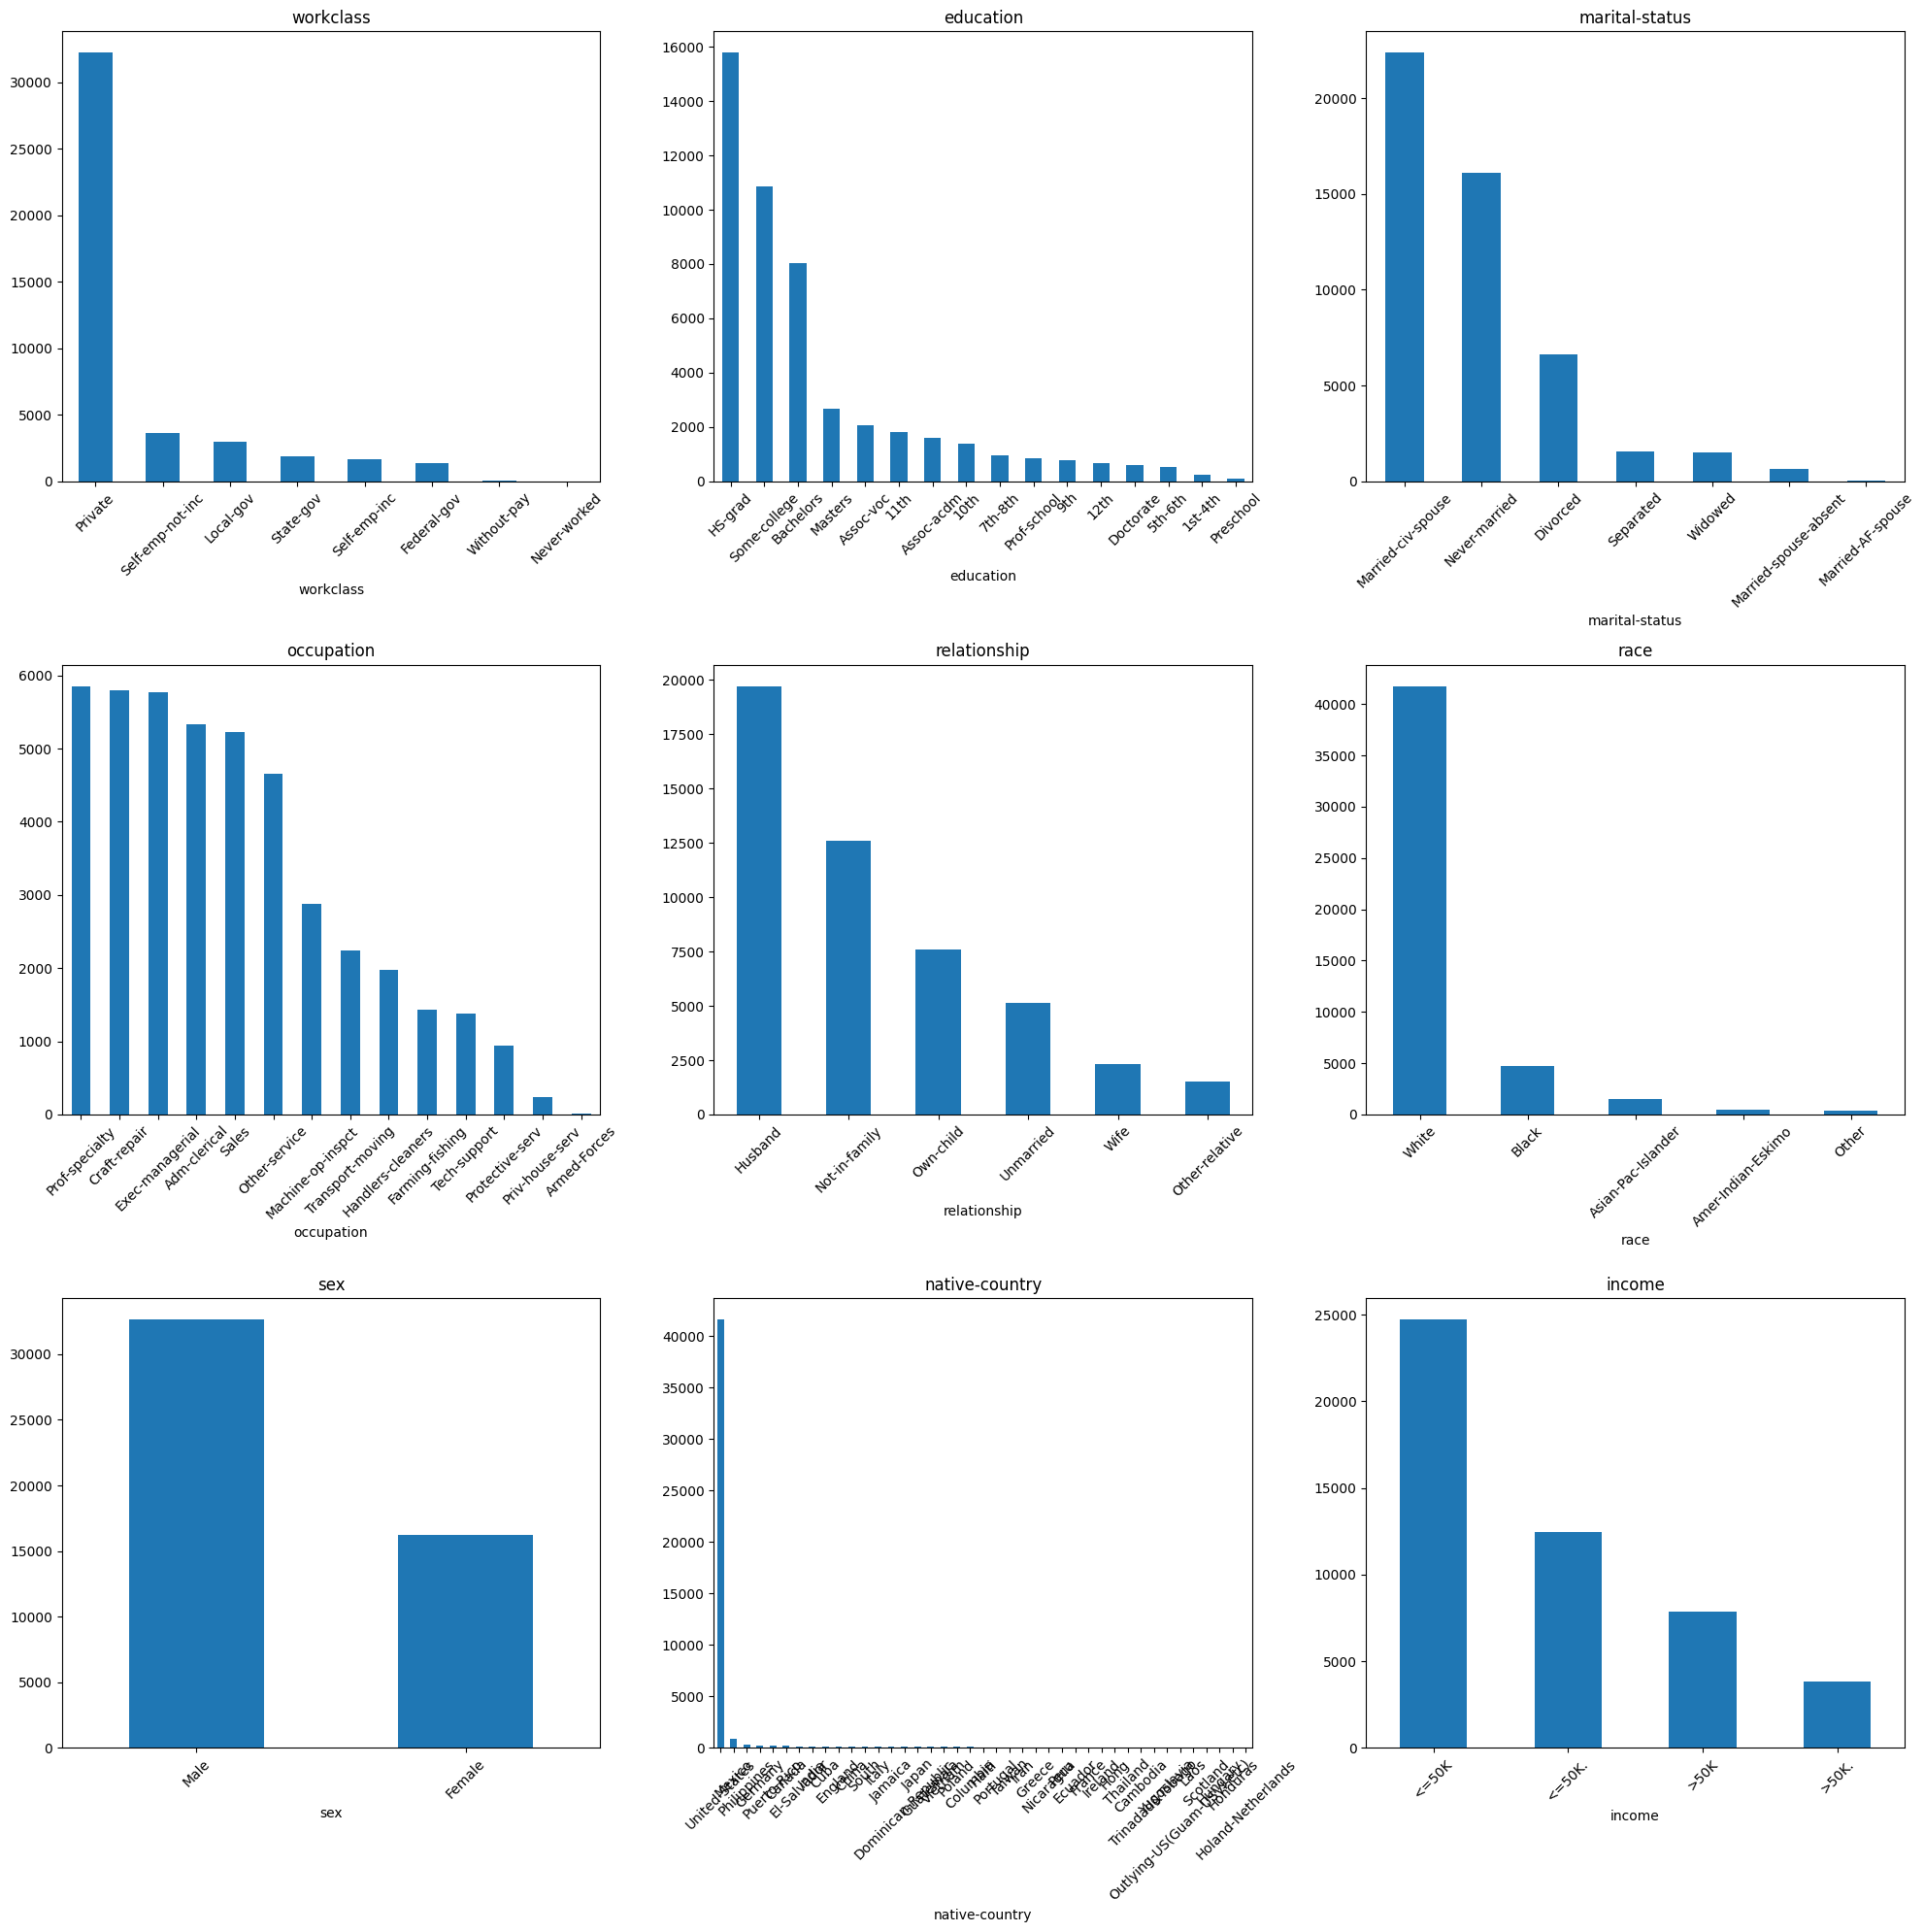

In [ ]:
plt.figure(figsize=(20,20))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)
    df_adult[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
#Percentage of Missing Values
print((df_adult.isnull().sum()/len(df_adult))*100)

age                0.000000
workclass         10.493018
fnlwgt             0.000000
education          0.000000
education-num      0.000000
marital-status     0.000000
occupation        10.472544
relationship       0.000000
race               0.000000
sex                0.000000
capital-gain       0.000000
capital-loss       0.000000
hours-per-week     0.000000
native-country     6.674583
income             0.000000
dtype: float64


In [ ]:
#for workclass
df_adult['workclass'].fillna(df_adult['workclass'].mode()[0], inplace=True)

/tmp/ipykernel_12906/2253320546.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adult['workclass'].fillna(df_adult['workclass'].mode()[0], inplace=True)


In [ ]:
#for occupation
df_adult['occupation'].fillna(df_adult['occupation'].mode()[0], inplace=True)

/tmp/ipykernel_12906/1068224898.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adult['occupation'].fillna(df_adult['occupation'].mode()[0], inplace=True)


In [ ]:
#native-country
df_adult['native-country'].fillna(df_adult['native-country'].mode()[0], inplace=True)

/tmp/ipykernel_12906/61643197.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adult['native-country'].fillna(df_adult['native-country'].mode()[0], inplace=True)


In [ ]:
# After handling Missing Values
print((df_adult.isnull().sum()/len(df_adult))*100)

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education-num     0.0
marital-status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital-gain      0.0
capital-loss      0.0
hours-per-week    0.0
native-country    0.0
income            0.0
dtype: float64


In [ ]:
df_adult.dropna(axis=0, inplace=True)
df_adult.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
print("After:", df_adult.shape)

After: (48842, 15)


## Handling Outliers

In [ ]:
df_adult.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.595164,1.896641e+05,10.078089,1079.067626,87.502314,40.426170
std,13.604587,1.056040e+05,2.570973,7452.019058,403.004552,12.327157
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


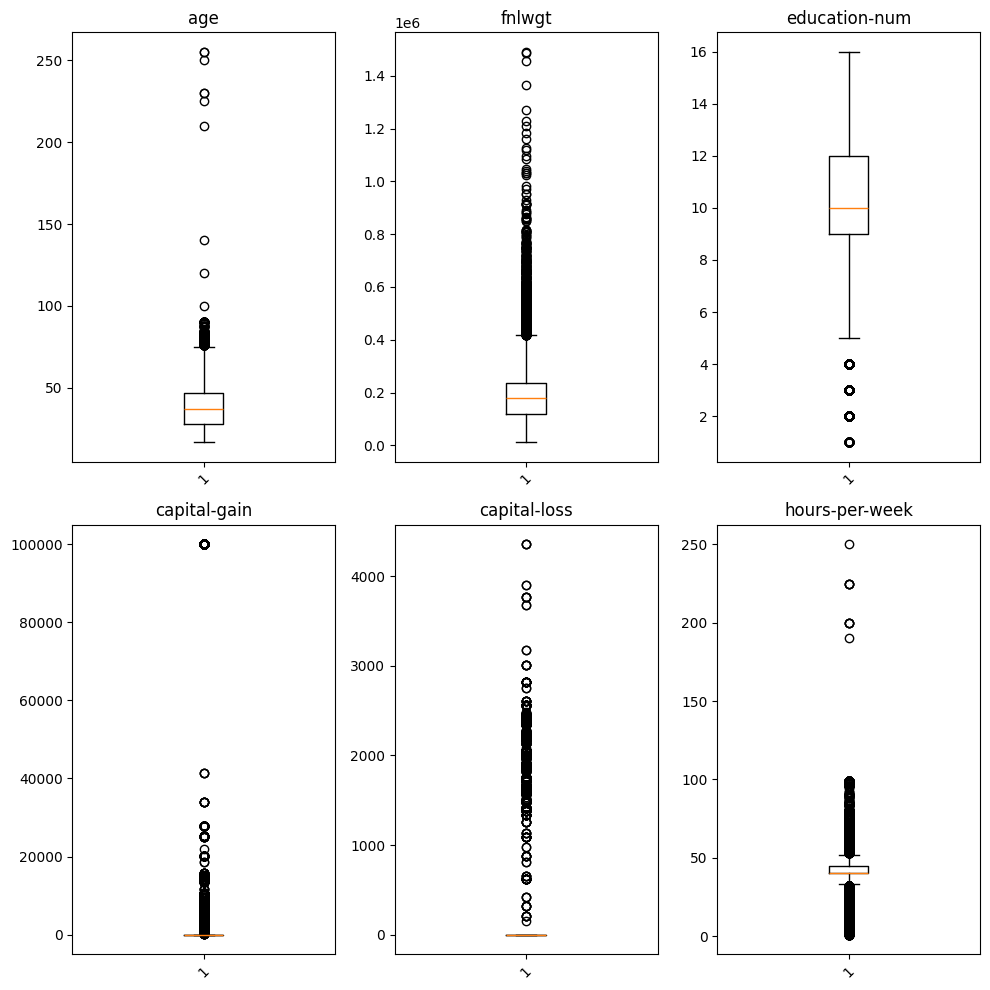

In [ ]:
plt.figure(figsize=(10,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df_adult[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
Q1 = df_adult[num_cols].quantile(0.25)

Q3 = df_adult[num_cols].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3+ (1.5 * IQR)
lower_limit = Q1- (1.5 * IQR)

outliers = ((df_adult[num_cols] > upper_limit)|(df_adult[num_cols] < lower_limit)).any(axis = 1)

outliers_df = df_adult[outliers]
outlier_percentage = len(outliers_df)* 100/len(df_adult)

print('percentage of outliers in the dataframe: ', outlier_percentage)

percentage of outliers in the dataframe:  40.448794070676875


In [ ]:
# This high percentage is mainly due to heavily skewed numerical features such as capital-gain, capital-loss, and fnlwgt,
# which naturally contain large variations and long-tailed distributions.
# Instead of removing rows containing extreme values, the clip() function was used to cap values outside the acceptable range.
# This approach preserved the dataset size

In [ ]:
outlier_cols = ["age", "fnlwgt","education-num" ]

In [ ]:
df_adult[outlier_cols] = df_adult[outlier_cols].clip(lower_limit, upper_limit, axis=1)

In [ ]:
df_adult.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.531387,186770.707163,10.122088,1079.067626,87.502314,40.426170
std,13.271160,95328.614282,2.456895,7452.019058,403.004552,12.327157
min,17.000000,12285.000000,4.500000,0.000000,0.000000,1.000000
25%,28.000000,117550.500000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,178144.500000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,237642.000000,12.000000,0.000000,0.000000,45.000000
max,75.500000,417779.250000,16.000000,99999.000000,4356.000000,250.000000


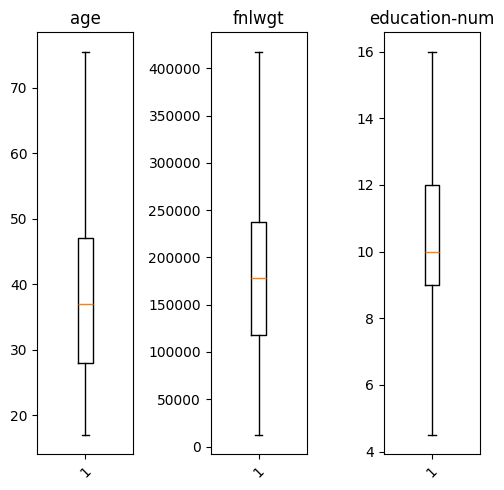

In [ ]:
plt.figure(figsize=(5,5))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(1, 3, i)
    plt.boxplot(df_adult[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

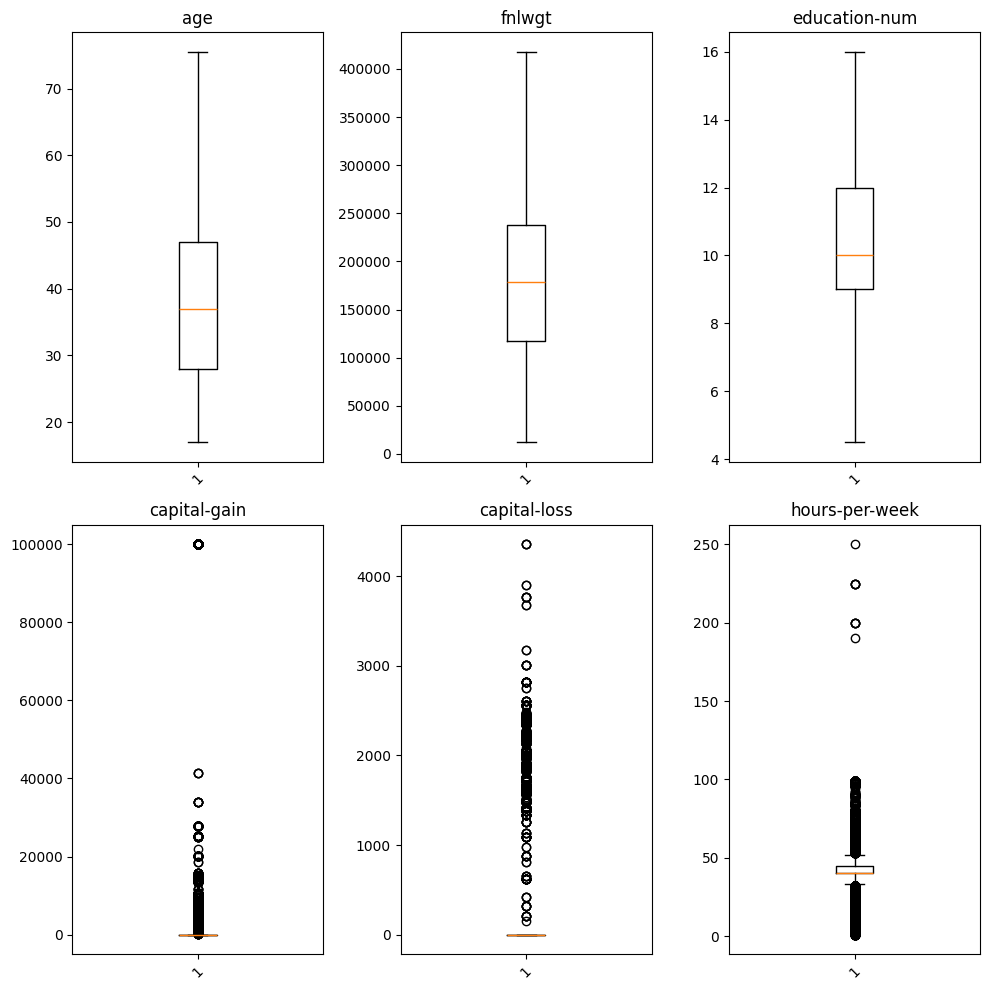

In [ ]:
plt.figure(figsize=(10,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df_adult[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Removing Unwanted Columns

In [ ]:
#correlation
corr_matrix = df_adult[num_cols].corr(method ='pearson')
corr_matrix

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.077034,0.041776,0.075451,0.056512,0.076561
fnlwgt,-0.077034,1.000000,-0.034922,-0.003104,-0.002718,-0.011664
education-num,0.041776,-0.034922,1.000000,0.129124,0.083317,0.139839
capital-gain,0.075451,-0.003104,0.129124,1.000000,-0.031441,0.079858
capital-loss,0.056512,-0.002718,0.083317,-0.031441,1.000000,0.050937
hours-per-week,0.076561,-0.011664,0.139839,0.079858,0.050937,1.000000


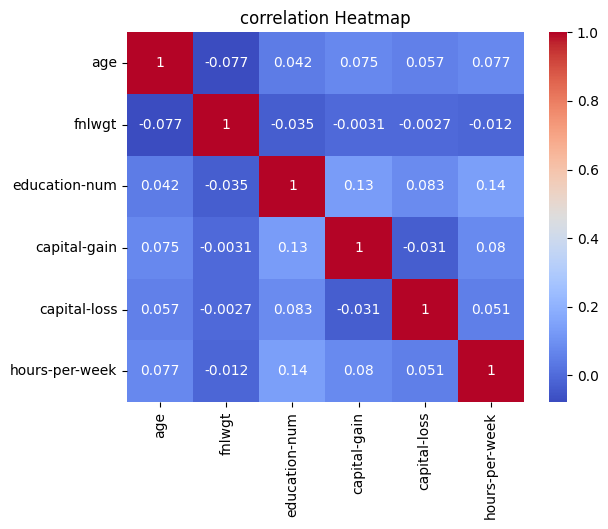

In [ ]:
#plotting a heat map to visualise correlation
sns.heatmap(corr_matrix, annot=True,cmap = 'coolwarm')
plt.title("correlation Heatmap")
plt.show()

## Data Transformation

### Scaling

In [ ]:
standard_scaler = StandardScaler()
df_adult[num_cols] = standard_scaler.fit_transform(
    df_adult[num_cols])

In [ ]:
#before scaling
df_adult.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,4.884200e+04,4.884200e+04,4.884200e+04,4.884200e+04,4.884200e+04,4.884200e+04
mean,-1.786468e-16,1.774829e-17,-3.207786e-16,1.018345e-17,-9.892491e-18,1.949403e-17
std,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00
min,-1.622436e+00,-1.830379e+00,-2.288313e+00,-1.448035e-01,-2.171271e-01,-3.198351e+00
25%,-7.935625e-01,-7.261295e-01,-4.567143e-01,-1.448035e-01,-2.171271e-01,-3.457200e-02
50%,-1.153933e-01,-9.049010e-02,-4.969232e-02,-1.448035e-01,-2.171271e-01,-3.457200e-02
75%,6.381281e-01,5.336468e-01,7.643517e-01,-1.448035e-01,-2.171271e-01,3.710407e-01
max,2.785664e+00,2.423311e+00,2.392440e+00,1.327438e+01,1.059179e+01,1.700116e+01


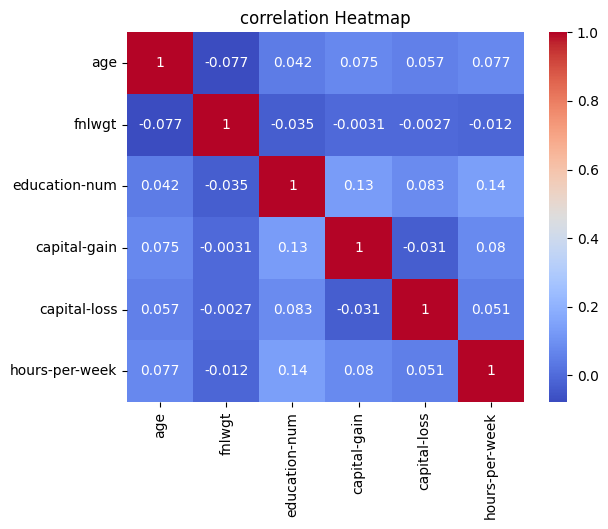

In [ ]:
#correlation after scaling
corr_matrix = df_adult[num_cols].corr(method ='pearson')
corr_matrix

sns.heatmap(corr_matrix, annot=True,cmap = 'coolwarm')
plt.title("correlation Heatmap")
plt.show()

## Encoding

In [ ]:
#Before
df_adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0.035311,State-gov,-1.146097,Bachelors,1.171374,Never-married,Adm-clerical,Not-in-family,White,Male,0.146932,-0.217127,-0.034572,United-States,<=50K
1,0.864184,Self-emp-not-inc,-1.085307,Bachelors,1.171374,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.144804,-0.217127,-2.224880,United-States,<=50K
2,-0.040041,Private,0.302906,HS-grad,-0.456714,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.144804,-0.217127,-0.034572,United-States,<=50K
3,1.090241,Private,0.503005,11th,-1.270758,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.144804,-0.217127,-0.034572,United-States,<=50K
4,-0.793562,Private,1.590706,Bachelors,1.171374,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.144804,-0.217127,-0.034572,Cuba,<=50K


In [ ]:
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

In [ ]:
label_encoder = LabelEncoder()
df_adult['sex'] = label_encoder.fit_transform(df_adult['sex'])

In [ ]:
df_adult['marital-status'] = label_encoder.fit_transform(df_adult['marital-status'])

In [ ]:
df_adult['race'] = label_encoder.fit_transform(df_adult['race'])

In [ ]:
df_adult['occupation'] =label_encoder.fit_transform(df_adult['occupation'])

In [ ]:
df_adult['relationship'] =label_encoder.fit_transform(df_adult['relationship'])

In [ ]:
df_adult['workclass'] =label_encoder.fit_transform(df_adult['workclass'])

In [ ]:
df_adult['education'] =label_encoder.fit_transform(df_adult['education'])

In [ ]:
#doing one hot encoding on mentioned coulmns
df_adult = pd.get_dummies(df_adult, columns =['education'],dtype =int)

In [ ]:
# The income column was removed before clustering because it acts as a predefined label and clustering is an unsupervised learning
# technique that should identify hidden groups without target information. Additionally, the native-country feature
# was considered optional due to its high cardinality and heavily skewed distribution,
# which could introduce noise and affect clustering quality.

In [ ]:
df_adult.drop(['native-country', 'income'],
                axis=1,
                inplace=True)

In [ ]:
df_adult.head()

,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,race,sex,capital-gain,...,education_6,education_7,education_8,education_9,education_10,education_11,education_12,education_13,education_14,education_15
0,0.035311,6,-1.146097,1.171374,4,0,1,4,1,0.146932,...,0,0,0,1,0,0,0,0,0,0
1,0.864184,5,-1.085307,1.171374,2,3,0,4,1,-0.144804,...,0,0,0,1,0,0,0,0,0,0
2,-0.040041,3,0.302906,-0.456714,0,5,1,4,1,-0.144804,...,0,0,0,0,0,1,0,0,0,0
3,1.090241,3,0.503005,-1.270758,2,5,0,2,1,-0.144804,...,0,0,0,0,0,0,0,0,0,0
4,-0.793562,3,1.590706,1.171374,2,9,5,2,0,-0.144804,...,0,0,0,1,0,0,0,0,0,0


##CLUSTERING

In [ ]:
X = df_adult

In [ ]:
wcss = []

# Finding WCSS value for different K values
for i in range(1, 11):
    k_means_model = KMeans(n_clusters=i, n_init=5)

    k_means_model.fit(X)

    # WCSS value
    wcss_value = k_means_model.inertia_

    wcss.append(wcss_value)

print(wcss)

[1421541.2822980245, 833652.4010359049, 738466.0933732374, 683788.2044140055, 634382.4884319225, 610029.5136125481, 566951.5046015374, 557660.316125885, 512376.6962122736, 491868.9804205828]


In [ ]:
#checking WCSS values
wcss

[1421541.2822980245,
 833652.4010359049,
 738466.0933732374,
 683788.2044140055,
 634382.4884319225,
 610029.5136125481,
 566951.5046015374,
 557660.316125885,
 512376.6962122736,
 491868.9804205828]

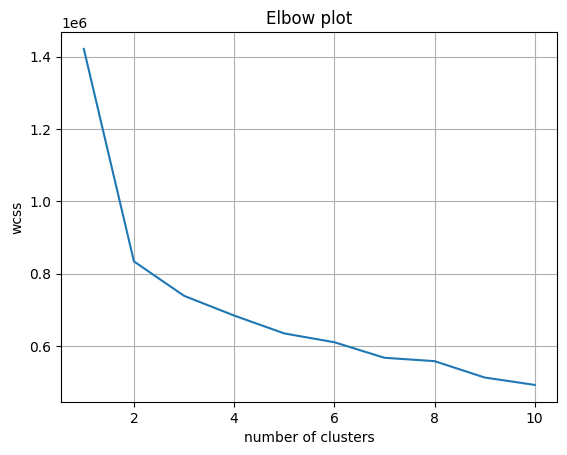

In [ ]:
plt.plot(range(1,11), wcss)
plt.title("Elbow plot")
plt.xlabel("number of clusters")
plt.ylabel("wcss" )
plt.grid()
plt.show()